In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk import pos_tag
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('stopwords')
from wordcloud import WordCloud
import os
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abhik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\abhik\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abhik\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Load Udemy CSV dataset till 2023
df = pd.read_csv("data/udemy_data_till_2023.csv")
df.head(3)

,id,title,is_paid,price,headline,num_subscribers,avg_rating,num_reviews,num_comments,num_lectures,content_length_min,published_time,last_update_date,category,subcategory,topic,language,course_url,instructor_name,instructor_url
0,4715.0,Online Vegan Vegetarian Cooking School,True,24.99,Learn to cook delicious vegan recipes. Filmed ...,2231.0,3.75,134.0,42.0,37.0,1268.0,2010-08-05T22:06:13Z,2020-11-06,Lifestyle,Food & Beverage,Vegan Cooking,English,/course/vegan-vegetarian-cooking-school/,Angela Poch,/user/angelapoch/
1,1769.0,The Lean Startup Talk at Stanford E-Corner,False,0.00,Debunking Myths of Entrepreneurship A startup ...,26474.0,4.50,709.0,112.0,9.0,88.0,2010-01-12T18:09:46Z,NaN,Business,Entrepreneurship,Lean Startup,English,/course/the-lean-startup-debunking-myths-of-en...,Eric Ries,/user/ericries/
2,5664.0,"How To Become a Vegan, Vegetarian, or Flexitarian",True,19.99,Get the tools you need for a lifestyle change ...,1713.0,4.40,41.0,13.0,14.0,82.0,2010-10-13T18:07:17Z,2019-10-09,Lifestyle,Other Lifestyle,Vegan Cooking,English,/course/see-my-personal-motivation-for-becomin...,Angela Poch,/user/angelapoch/


In [3]:
df.tail(3)

,id,title,is_paid,price,headline,num_subscribers,avg_rating,num_reviews,num_comments,num_lectures,content_length_min,published_time,last_update_date,category,subcategory,topic,language,course_url,instructor_name,instructor_url
209731,4914002.0,CISSP 4 full exams #1 : All CISSP domains - 12...,True,49.99,Practice Latest exam questions with detailed e...,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-05T11:04:05Z,2022-10-05,IT & Software,IT Certifications,CISSP - Certified Information Systems Security...,English,/course/cissp-4-full-exams-1-all-cissp-domains...,Jean-François d'Halluin,/user/badre-lini/
209732,4913934.0,JD Edwards EnterpriseOne Fixed Assets Accounti...,True,119.99,Full-length course (Part-3 of 3) on JD Edwards...,0.0,0.0,0.0,0.0,9.0,82.0,2022-10-05T10:30:19Z,2022-10-05,Finance & Accounting,Other Finance & Accounting,Financial Accounting,English,/course/jde-fixed-assets-accounting-part-3/,Niranjan Bhatia,/user/systemic-software-solutions/
209733,4914054.0,CISSP 4 full exams #2 : All CISSP domains - 12...,True,49.99,Practice Latest exam questions with detailed e...,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-05T11:36:34Z,2022-10-05,IT & Software,IT Certifications,CISSP - Certified Information Systems Security...,English,/course/cissp-4-full-exams-2-all-cissp-domains...,Jean-François d'Halluin,/user/badre-lini/


### info about null values and datatype

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209734 entries, 0 to 209733
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  209734 non-null  float64
 1   title               209734 non-null  object 
 2   is_paid             209734 non-null  bool   
 3   price               209734 non-null  float64
 4   headline            209703 non-null  object 
 5   num_subscribers     209734 non-null  float64
 6   avg_rating          209734 non-null  float64
 7   num_reviews         209734 non-null  float64
 8   num_comments        209734 non-null  float64
 9   num_lectures        209734 non-null  float64
 10  content_length_min  209734 non-null  float64
 11  published_time      209734 non-null  object 
 12  last_update_date    209597 non-null  object 
 13  category            209734 non-null  object 
 14  subcategory         209734 non-null  object 
 15  topic               208776 non-nul

In [5]:
num_col=[col for col in df.columns.tolist() if df[col].dtype in ('int64','float64')] 
text_col=[col for col in df.columns.tolist() if df[col].dtype not in ('int64','float64')] 
print(num_col)
print(text_col)

['id', 'price', 'num_subscribers', 'avg_rating', 'num_reviews', 'num_comments', 'num_lectures', 'content_length_min']
['title', 'is_paid', 'headline', 'published_time', 'last_update_date', 'category', 'subcategory', 'topic', 'language', 'course_url', 'instructor_name', 'instructor_url']


In [6]:
df.isnull().sum()

id                      0
title                   0
is_paid                 0
price                   0
headline               31
num_subscribers         0
avg_rating              0
num_reviews             0
num_comments            0
num_lectures            0
content_length_min      0
published_time          0
last_update_date      137
category                0
subcategory             0
topic                 958
language                0
course_url              0
instructor_name         5
instructor_url        427
dtype: int64

In [7]:
#there are null values present in data. lets find percentage of missing values in each feature
df.isnull().sum() * 100/df.shape[0]
# less than 1 percent null values found hence we can drop some samples

id                    0.000000
title                 0.000000
is_paid               0.000000
price                 0.000000
headline              0.014781
num_subscribers       0.000000
avg_rating            0.000000
num_reviews           0.000000
num_comments          0.000000
num_lectures          0.000000
content_length_min    0.000000
published_time        0.000000
last_update_date      0.065321
category              0.000000
subcategory           0.000000
topic                 0.456769
language              0.000000
course_url            0.000000
instructor_name       0.002384
instructor_url        0.203591
dtype: float64

### drop samples with rows full of null values if any

In [8]:
df = df.dropna()

### drop duplicates if any

In [9]:
df.drop_duplicates(inplace=True)
df.drop_duplicates(subset=['id'],inplace=True)
df.reset_index(drop=True, inplace=True)

### converting is_paid category column(true and false) into 2 categories paid and free

In [10]:
df['is_paid'][df['is_paid']==True]='Paid'
df['is_paid'][df['is_paid']==False]='Free'

In [11]:
df['is_paid'].value_counts()

is_paid
Paid    186662
Free     21524
Name: count, dtype: int64

### some titles are blank hence preprocessing is required

In [12]:
df['title'] = df['title'].astype(str).str.strip()
df = df[df['title'] != '']

In [13]:
df[df['title']=='']

,id,title,is_paid,price,headline,num_subscribers,avg_rating,num_reviews,num_comments,num_lectures,content_length_min,published_time,last_update_date,category,subcategory,topic,language,course_url,instructor_name,instructor_url


In [14]:
df[df['headline']=='']

,id,title,is_paid,price,headline,num_subscribers,avg_rating,num_reviews,num_comments,num_lectures,content_length_min,published_time,last_update_date,category,subcategory,topic,language,course_url,instructor_name,instructor_url


### removing very rare language courses 

In [15]:
print(df['language'].value_counts())

language
English       122829
Portuguese     18391
Spanish        17343
Turkish         8042
Japanese        6975
               ...  
Basque             1
Xhosa              1
Tajik              1
Faroese            1
Guaraní            1
Name: count, Length: 79, dtype: int64


In [16]:
df=df[df['language'].map(df['language'].value_counts()) >= 2]

### converting two sub chinese languages into - basic chinese

In [17]:
df['language'][df['language'].str.contains('Chinese')].value_counts()

language
Traditional Chinese    1010
Simplified Chinese      984
Name: count, dtype: int64

In [18]:
df['language'] = df['language'].apply(lambda x: 'Chinese' if 'Chinese' in x else x)

### convert data type of published_time,last_update to datetime format

In [19]:
df['published_time'] = pd.to_datetime(df['published_time'])  # ensure datetime type
df['last_update_date'] = pd.to_datetime(df['last_update_date'])  # ensure datetime type
# df['published_time'] = df['published_time'].dt.tz_localize(None).dt.date
# df['last_update_date'] = df['last_update_date'].dt.tz_localize(None).dt.date

### statistics

In [20]:
df.describe()
# max price of course amongst all is 1000 dollars/rupees
# average price of all courses is around 81 dollars/rupees
# averagely each course having 244 no_of reviews
# we found out few courses having 0 lectures and 0 content length which is not possible
# we need to fill those values by fetching from website using beautifulsoup and udemy api

,id,price,num_subscribers,avg_rating,num_reviews,num_comments,num_lectures,content_length_min,last_update_date
count,2.081760e+05,208176.000000,2.081760e+05,208176.000000,208176.000000,208176.000000,208176.000000,208176.000000,208176
mean,3.013382e+06,81.755452,3.105029e+03,3.751656,245.393878,45.070685,36.641284,266.216581,2020-10-25 22:42:59.432787968
min,2.762000e+03,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2012-10-31 00:00:00
25%,1.949328e+06,19.990000,2.600000e+01,3.800000,3.000000,1.000000,11.000000,69.000000,2020-02-18 00:00:00
50%,3.286962e+06,34.990000,2.070000e+02,4.333334,17.000000,5.000000,22.000000,133.000000,2021-04-27 00:00:00
75%,4.184957e+06,99.990000,1.441000e+03,4.625000,75.000000,18.000000,42.000000,290.000000,2022-03-17 00:00:00
max,4.914146e+06,999.990000,1.752364e+06,5.000000,436457.000000,39040.000000,1095.000000,22570.000000,2022-10-10 00:00:00
std,1.340777e+06,117.375845,1.561981e+04,1.529449,2466.405305,357.009065,51.941315,455.301612,NaN


#### checking how many null values present in content_length_min and num_lectures both

In [21]:
print(df[df['content_length_min']==0].shape)
print(df[df['num_lectures']==0].shape)

(9001, 20)
(8965, 20)


In [22]:
# for example: course having 0 content length
df['course_url'][df['content_length_min']==0].head(2).tolist()[1]

'/course/akvarium-a-viz-alatti-mesterseges-csoda/'

#### WE NEED TO FILL NUM_LECTURES AND CONTENT_LENGTH DATA BY FETCHING FROM WEBSITE 
#### USING BEAUTIFULSOUP AND UDEMY API

In [23]:
# import requests
# from tqdm import tqdm

# HEADERS = {
#     "X-RapidAPI-Key": "2b54f98505mshdf3024db63be453p1a452ejsn76a9b022195c",
#     "X-RapidAPI-Host": "udemy-course-scraper-api.p.rapidapi.com"
# }

# def fetch_course_details(course_id):
#     api_url = f"https://www.udemy.com/api-2.0/courses/{course_id}/?fields[course]=@default,num_published_lectures,content_info"
#     try:
#         response = requests.get(api_url, headers=HEADERS, timeout=10)
#         if response.status_code == 404:
#             return None, None, False   # mark as failed
#         response.raise_for_status()
#         data = response.json()
#         num_lectures = data.get("num_published_lectures")
#         content_info = data.get("content_info")
#         return num_lectures, content_info, True
#     except requests.exceptions.RequestException:
#         return None, None, False

# def update_missing_courses(df):
#     failed_ids = []
#     mask = (df['content_length_min'] == 0) | (df['num_lectures'] == 0)
#     idxs = df[mask].index.tolist()
#     print(f"Found {len(idxs)} courses to update...")

#     for idx in tqdm(idxs, desc="Fetching courses"):
#         course_id = df.at[idx, 'id']
#         num_lectures, content_info, success = fetch_course_details(course_id)
#         if success:
#             if num_lectures is not None:
#                 df.at[idx, 'num_lectures'] = num_lectures
#             if content_info is not None:
#                 df.at[idx, 'content_length_min'] = content_info
#         else:
#             failed_ids.append(course_id)

#     print(f"✅ Finished updating dataframe. Failed: {len(failed_ids)}")
#     return df, failed_ids

# df, failed_ids = update_missing_courses(df)
# print(len(failed_ids))
# # df = df[~df['id'].isin(failed_ids)]   # drop failed if you want


#### we tried to fetch latest data based on id and course url but we didnt find 9001 courses are unlisted from udemy hence dropping this all samples

In [24]:
# failed_ids=list(map(lambda x: int(x), failed_ids))
# failed_ids[0:5]

In [25]:
failed_ids=df['id'].astype(int)[(df['content_length_min']==0) | (df['num_lectures']==0)].tolist()

In [26]:
print('before dropping', df.shape)
# 208176 - 9001 = 199175
df=df[~df['id'].isin(failed_ids)]
print('after dropping', df.shape)

before dropping (208176, 20)
after dropping (199175, 20)


In [27]:
df.shape

(199175, 20)

In [28]:
df.reset_index(drop=True, inplace=True)

In [29]:
df.loc[980].headline

'動画で学ぶ電気回路の基礎\u3000〜キルヒホッフから回路解析まで〜'

In [30]:
df.loc[2706].headline

'Simple, easy step by step approach to creating your own applications using UserForms in Excel'

### checking content_length

In [31]:
df['content_length_min'].describe()
#we found out that there might be some incorrect values in content_length_min feature or courses having very less content length

count    199175.000000
mean        278.247285
std         461.866039
min           1.000000
25%          76.000000
50%         142.000000
75%         302.000000
max       22570.000000
Name: content_length_min, dtype: float64

In [32]:
#finding courses having less than 15 minute content length
df[df['content_length_min']<20].shape
#we found out that few courses having less than 20 minute content length which is not possible hence dropping those samples
df=df[df['content_length_min']>=20]

In [33]:
print(df.shape)
print(df[df['content_length_min']<100].shape)
print(df[(df['content_length_min']>=100) & (df['content_length_min']<=240)].shape)
print(df[(df['content_length_min']>=240)].shape)
#hence i will convert content_length_min feature into categorical feature short, medium, long

(199120, 20)
(69782, 20)
(66003, 20)
(63588, 20)


In [34]:
def categorize_content_length(minutes):
    if minutes < 100:
        return 'Short'
    elif 100 <= minutes <= 240:
        return 'Medium'
    else:
        return 'Long'

df['content_length_minutes'] = df['content_length_min'].apply(categorize_content_length)
df['content_length_minutes'].value_counts()

content_length_minutes
Short     69782
Medium    66003
Long      63335
Name: count, dtype: int64

In [35]:
df.reset_index(drop=True, inplace=True)

In [36]:
df.columns

Index(['id', 'title', 'is_paid', 'price', 'headline', 'num_subscribers',
       'avg_rating', 'num_reviews', 'num_comments', 'num_lectures',
       'content_length_min', 'published_time', 'last_update_date', 'category',
       'subcategory', 'topic', 'language', 'course_url', 'instructor_name',
       'instructor_url', 'content_length_minutes'],
      dtype='object')

In [37]:
df.head(2).values

array([[4715.0, 'Online Vegan Vegetarian Cooking School', 'Paid', 24.99,
        "Learn to cook delicious vegan recipes. Filmed over 15 years ago, watch the first 2hrs FREE to see if it's right for you.",
        2231.0, 3.75, 134.0, 42.0, 37.0, 1268.0,
        Timestamp('2010-08-05 22:06:13+0000', tz='UTC'),
        Timestamp('2020-11-06 00:00:00'), 'Lifestyle', 'Food & Beverage',
        'Vegan Cooking', 'English',
        '/course/vegan-vegetarian-cooking-school/', 'Angela Poch',
        '/user/angelapoch/', 'Long'],
       [5664.0, 'How To Become a Vegan, Vegetarian, or Flexitarian',
        'Paid', 19.99,
        'Get the tools you need for a lifestyle change that will bring you health and a clear conscience.',
        1713.0, 4.4, 41.0, 13.0, 14.0, 82.0,
        Timestamp('2010-10-13 18:07:17+0000', tz='UTC'),
        Timestamp('2019-10-09 00:00:00'), 'Lifestyle', 'Other Lifestyle',
        'Vegan Cooking', 'English',
        '/course/see-my-personal-motivation-for-becoming-veget

In [38]:
df.isnull().sum()

id                        0
title                     0
is_paid                   0
price                     0
headline                  0
num_subscribers           0
avg_rating                0
num_reviews               0
num_comments              0
num_lectures              0
content_length_min        0
published_time            0
last_update_date          0
category                  0
subcategory               0
topic                     0
language                  0
course_url                0
instructor_name           0
instructor_url            0
content_length_minutes    0
dtype: int64

In [39]:
str1='   abhi'
str1.strip()  # abhi

'abhi'

In [40]:
# df[df['title']=='nan']
df['title'] = df['title'].str.strip()
df['title'].isnull().sum()

np.int64(0)

In [41]:
df[df['title']==''].index

Index([], dtype='int64')

In [42]:
df[df['title']=='']

,id,title,is_paid,price,headline,num_subscribers,avg_rating,num_reviews,num_comments,num_lectures,...,published_time,last_update_date,category,subcategory,topic,language,course_url,instructor_name,instructor_url,content_length_minutes


# EDA

### countplot for checking counts paid and free courses

Text(0.5, 1.0, 'Distribution of Course Prices')

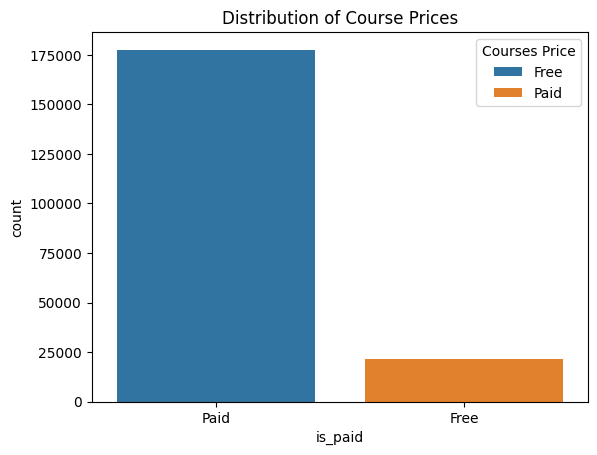

In [43]:
sns.countplot(data=df,x='is_paid',hue='is_paid')
plt.legend(title='Courses Price', labels=['Free', 'Paid'])
plt.title('Distribution of Course Prices')
# we can say that most of the courses are paid courses

<Axes: title={'center': 'Price Distribution of paid courses in dollars'}, xlabel='price'>

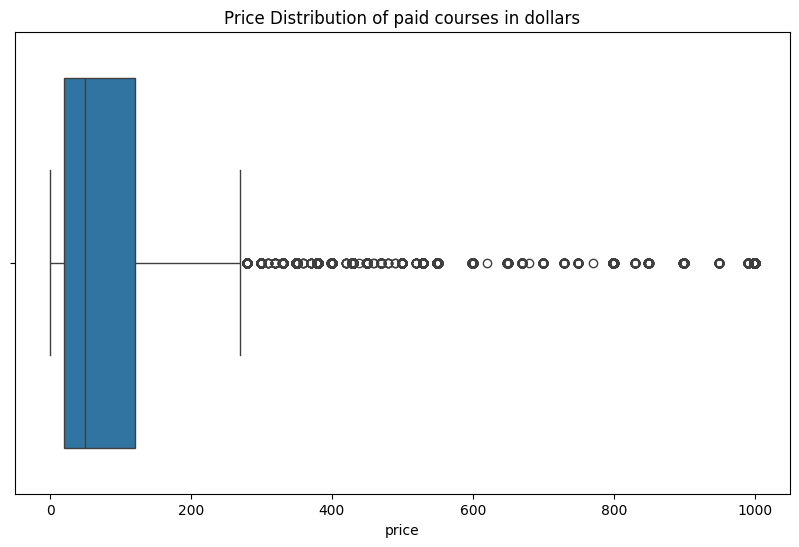

In [44]:
# checking price distribution
plt.figure(figsize=(10,6))
plt.title('Price Distribution of paid courses in dollars')
sns.boxplot(data=df[df['is_paid']=='Paid'], x='price')

### average rating distribution to check courses overall rating trend 

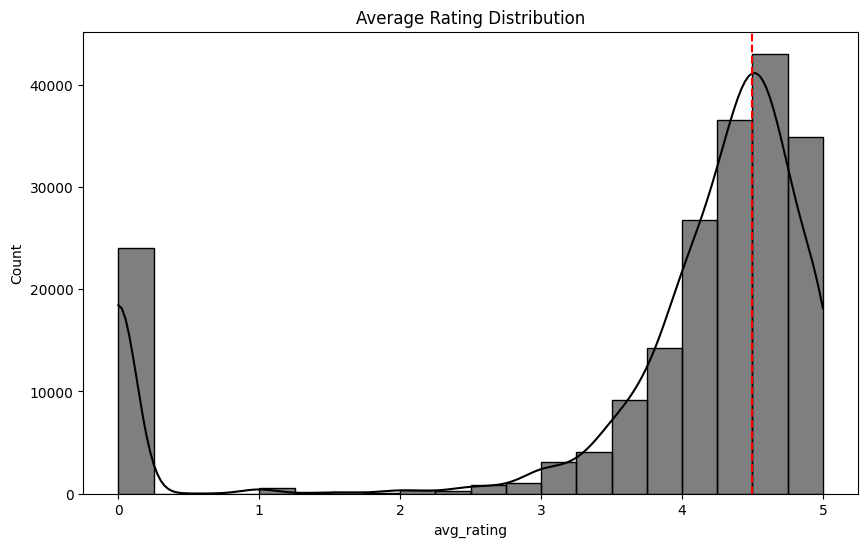

In [45]:
# Distribution, % of courses with perfect ratings
plt.figure(figsize=(10,6))
plt.title('Average Rating Distribution')
sns.histplot(data=df, x='avg_rating', bins=20, kde=True, color='black')
# we can say that most of the courses are having rating between 4 to 5
plt.axvline(x=4.5, color='r', linestyle='--')


Text(0.5, 0, 'Average Rating')

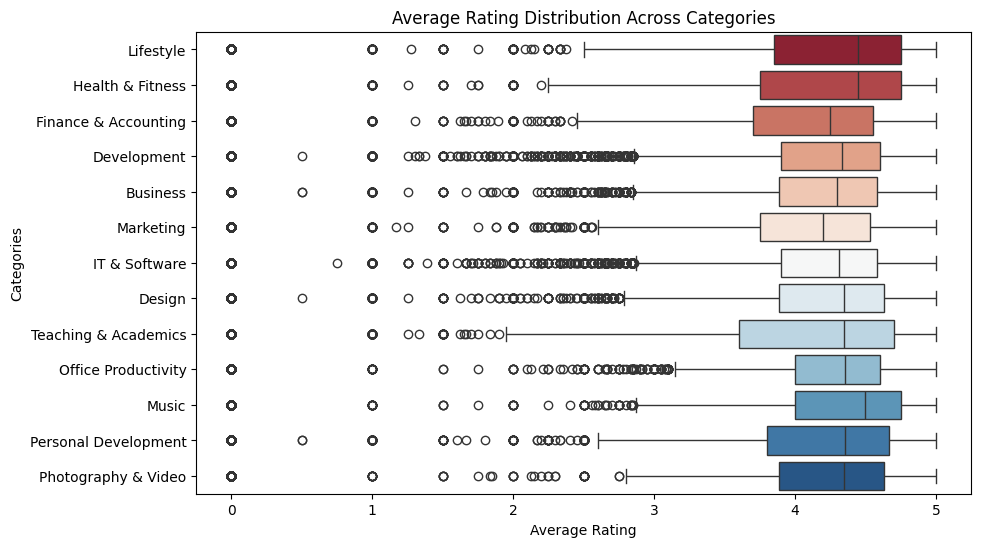

In [46]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='avg_rating', y='category',palette='RdBu')
plt.title("Average Rating Distribution Across Categories")
plt.ylabel("Categories")
plt.xlabel('Average Rating')
# we can say that category 'Health & Fitness' and 'Lifestyle' having highest average rating 
# category 'Marketing' having lowest average rating

### no of subscribers distribution

In [47]:
df[df['num_subscribers']>=10].shape

(167797, 21)

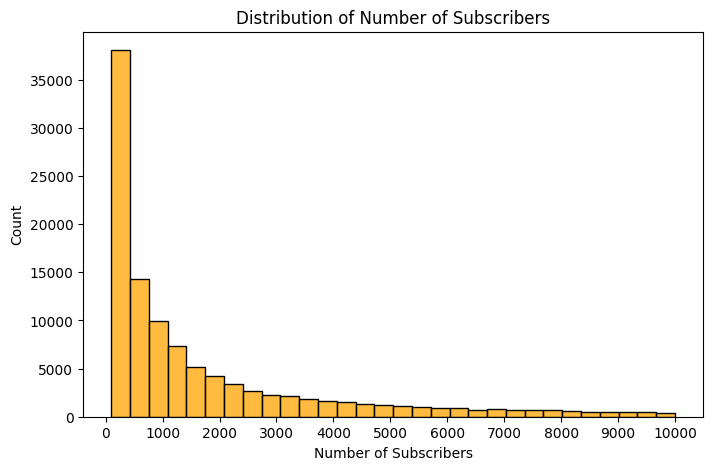

In [48]:
#lot of courses may have very less no of subscribers because they can be newly launched or not so popular
# we can see that most of the courses have less than 1000 subscribers, and very few courses having very high no of subscribers
plt.figure(figsize=(8,5))
sns.histplot(data=df[df['num_subscribers']>=100], x='num_subscribers', bins=30, binrange=(100, 10000), color='Orange')
plt.title('Distribution of Number of Subscribers')
plt.xlabel('Number of Subscribers')
plt.ylabel('Count')
plt.xticks(np.arange(0, 10001, step=1000))
plt.show()

### number of lectures overall look

In [49]:
df['num_lectures'][df['num_lectures']>=200].count()
#total 3590 courses having more than 200 lectures which we can say are very detailed courses


np.int64(3590)

In [50]:
df['num_lectures'][df['num_lectures']<2].count()

np.int64(7)

<Axes: xlabel='num_lectures', ylabel='Count'>

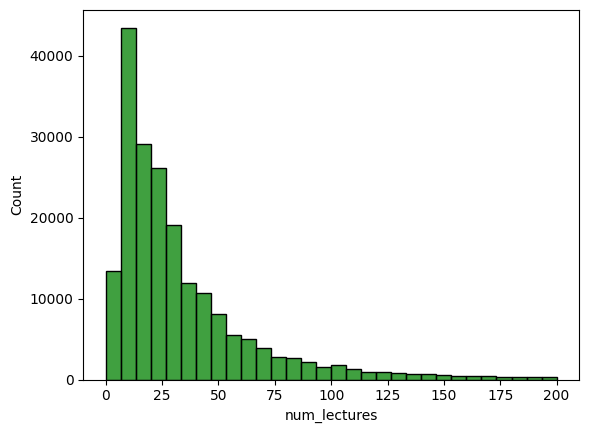

In [51]:
sns.histplot(data=df, x='num_lectures', bins=30, binrange=(0, 200),color='green')
# we can say that most of the courses having less than 100 lectures

### content length

In [52]:
df['content_length_min'][df['content_length_min']<1440].shape


(194669,)

<Axes: xlabel='content_length_min', ylabel='Count'>

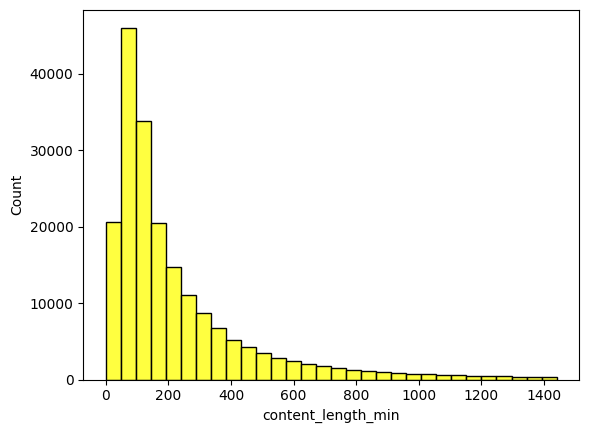

In [53]:
sns.histplot(data=df, x='content_length_min', bins=30,binrange=(0, 1440),color='Yellow')
# we can say that most of the courses having less than 1440 minutes of content 24 hrs
# maximum courses having content length between 50 to 150 minutes

### Growth of courses per year

In [54]:
year_wise = pd.to_datetime(df['published_time']).dt.year.value_counts().sort_index()
year_wise

published_time
2010        3
2011       42
2012      352
2013     1762
2014     3386
2015     7073
2016     7956
2017    12146
2018    20238
2019    22737
2020    42625
2021    47984
2022    32816
Name: count, dtype: int64

Text(0.5, 1.0, 'Number of Courses Published Each Year')

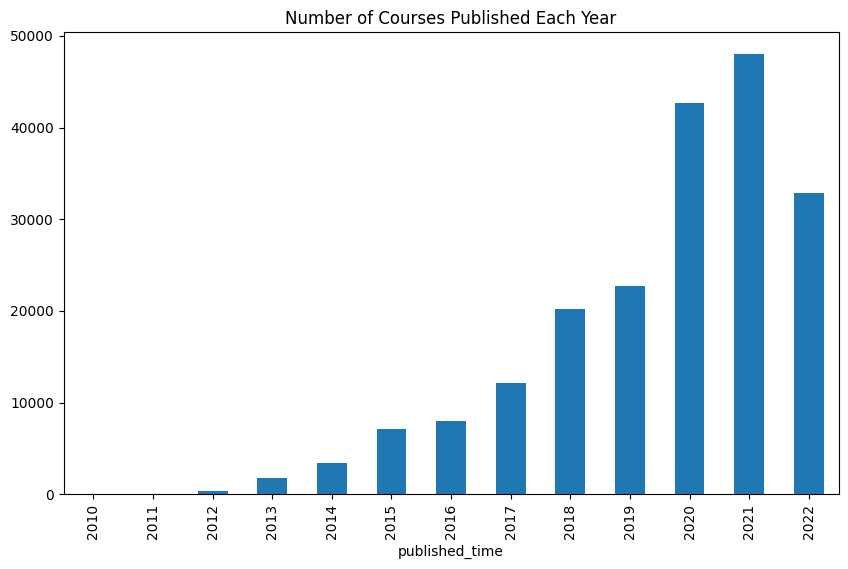

In [55]:
year_wise.plot(kind='bar', figsize=(10,6))
plt.title('Number of Courses Published Each Year')
# we can say that maximum courses are published in year 2020 and 2021
# minimum courses are published in year 2009 and 2010

### Growth of Subscribers over Time 

In [56]:
# Set the "published_time" column as the index
df_time = df.set_index("published_time")
# Resample the data to a monthly frequency and calculate the sum of subscribers for each month
monthly_subscribers = df_time["num_subscribers"].resample("M").sum()
monthly_subscribers

published_time
2010-04-30 00:00:00+00:00       3309.0
2010-05-31 00:00:00+00:00          0.0
2010-06-30 00:00:00+00:00          0.0
2010-07-31 00:00:00+00:00          0.0
2010-08-31 00:00:00+00:00       2231.0
                               ...    
2022-06-30 00:00:00+00:00    1706060.0
2022-07-31 00:00:00+00:00    1348864.0
2022-08-31 00:00:00+00:00    1209750.0
2022-09-30 00:00:00+00:00     903117.0
2022-10-31 00:00:00+00:00      68091.0
Freq: ME, Name: num_subscribers, Length: 151, dtype: float64

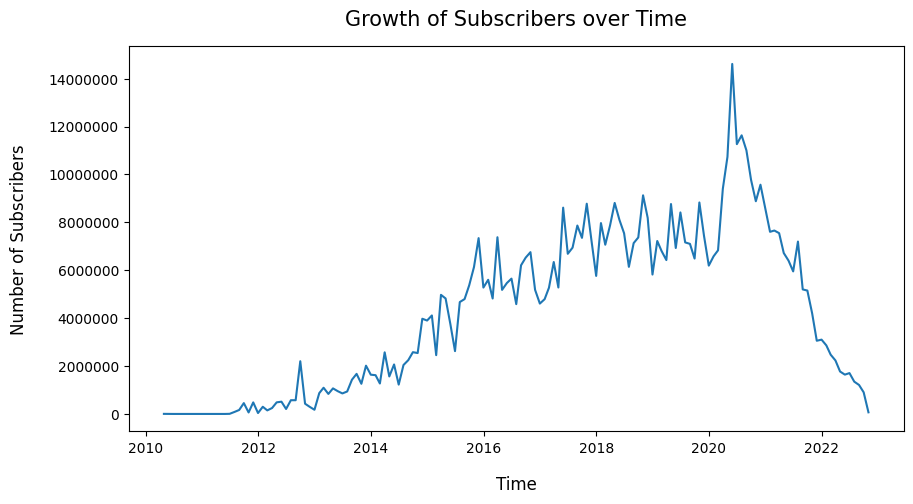

In [57]:
# Setting the plot's figure size
plt.subplots(figsize=(10, 5))
sns.lineplot(x=monthly_subscribers.index, y=monthly_subscribers.values)
# Set the title and axis labels
plt.title("Growth of Subscribers over Time", fontsize=15, pad=15)
plt.ylabel("Number of Subscribers", fontsize=12, labelpad=15)
plt.xlabel("Time",fontsize=12, labelpad=15)
plt.ticklabel_format(style='plain', axis='y')
plt.show()
# we can say that there is a steady growth in no of subscribers over time
# In 2021 maximum no of subscribers were added

### Total lectures per year

In [58]:
yearly_comments=df_time.resample("Y")["num_lectures"].sum()
yearly_comments

published_time
2010-12-31 00:00:00+00:00         59.0
2011-12-31 00:00:00+00:00       4178.0
2012-12-31 00:00:00+00:00      21350.0
2013-12-31 00:00:00+00:00      76303.0
2014-12-31 00:00:00+00:00     139919.0
2015-12-31 00:00:00+00:00     297739.0
2016-12-31 00:00:00+00:00     366610.0
2017-12-31 00:00:00+00:00     559331.0
2018-12-31 00:00:00+00:00     939742.0
2019-12-31 00:00:00+00:00     972078.0
2020-12-31 00:00:00+00:00    1569279.0
2021-12-31 00:00:00+00:00    1606334.0
2022-12-31 00:00:00+00:00    1074150.0
Freq: YE-DEC, Name: num_lectures, dtype: float64

In [59]:
yearly_comments.index.year

Index([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022],
      dtype='int32', name='published_time')

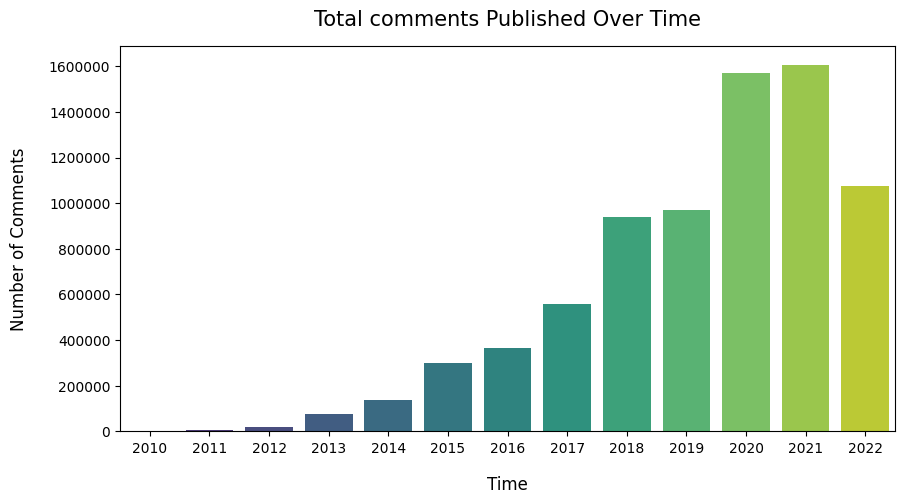

In [60]:
plt.subplots(figsize=(10, 5))
sns.barplot(x=yearly_comments.index.year, y=yearly_comments.values, palette="viridis")
plt.title("Total comments Published Over Time", fontsize=15, pad=15)
plt.ylabel("Number of Comments", fontsize=12, labelpad=15)
plt.xlabel("Time",fontsize=12, labelpad=15)
plt.ticklabel_format(style='plain', axis='y')
plt.show()
# In 2021 maximum number of comments were made

### Distribution of languages in which courses are offered  

In [61]:
top10_lang=df['language'].value_counts().head(10)
print(top10_lang)
percent_top10_lang=(top10_lang/df.shape[0] )* 100
print(percent_top10_lang)

language
English       114986
Portuguese     18010
Spanish        17014
Turkish         7972
Japanese        6883
German          6032
French          5310
Arabic          5127
Italian         3606
Russian         2660
Name: count, dtype: int64
language
English       57.747087
Portuguese     9.044797
Spanish        8.544596
Turkish        4.003616
Japanese       3.456710
German         3.029329
French         2.666734
Arabic         2.574829
Italian        1.810968
Russian        1.335878
Name: count, dtype: float64


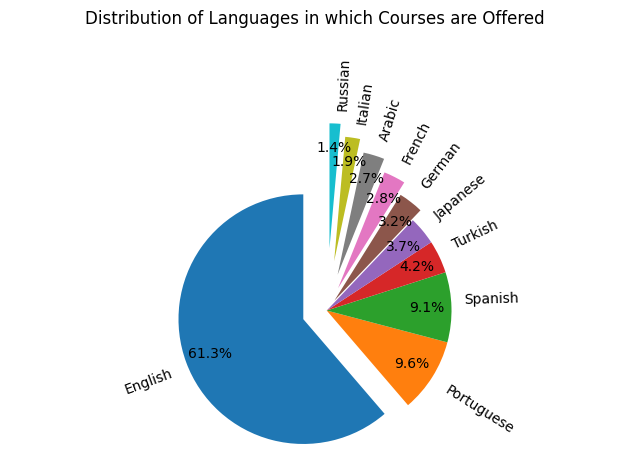

In [62]:
# plt.figure(figsize=(10, 5))
explode_list = [0.2, 0, 0, 0, 0, 0.1, 0.2, 0.3, 0.4, 0.5]
plt.pie(percent_top10_lang, labels=percent_top10_lang.index, autopct='%1.1f%%',startangle=90, rotatelabels=True,pctdistance=0.8, explode=explode_list)
plt.axis('equal')
plt.title('Distribution of Languages in which Courses are Offered', pad=60)
plt.tight_layout()
plt.show()
# we can say that most of the courses are offered in English language followed by Portugese and spanish

### Number of subscribers per category

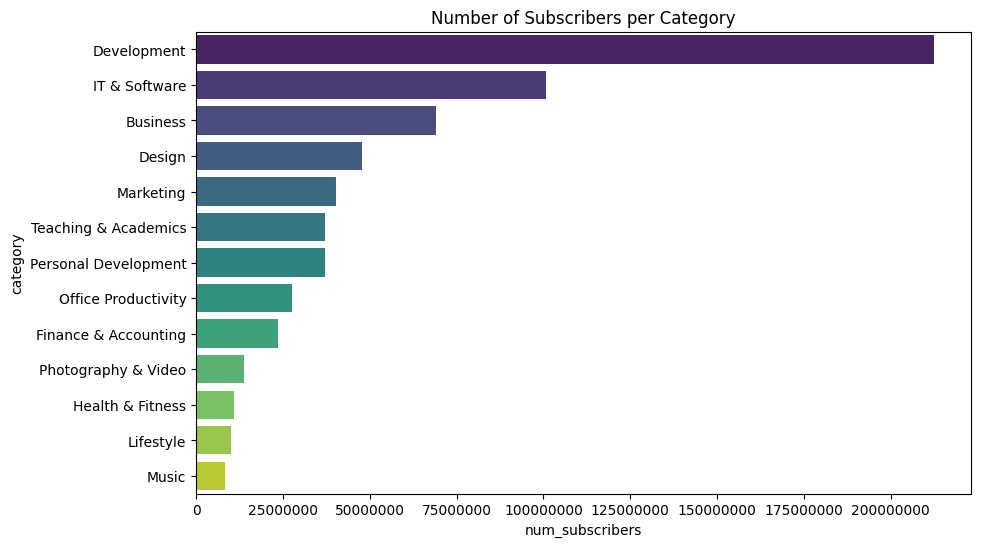

In [63]:
sub_per_cat=df.groupby('category')['num_subscribers'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(sub_per_cat,orient='h',palette='viridis')
plt.title('Number of Subscribers per Category')
plt.ticklabel_format(style='plain', axis='x')
# Development has the highest number of subscribers followed by IT & Software and Business
# Music has the least number of subscribers
# we can say that most of the people are interested in learning development skills

### Top 5 courses with highest number of reviews

In [64]:
df.sort_values(by='num_reviews', ascending=False).head(5)[['title','num_reviews']]

,title,num_reviews
10541,2022 Complete Python Bootcamp From Zero to Her...,436457.0
16087,Microsoft Excel - Excel from Beginner to Advanced,332598.0
11931,The Web Developer Bootcamp 2022,246624.0
38700,The Complete 2022 Web Development Bootcamp,228108.0
15180,Angular - The Complete Guide (2022 Edition),172991.0


### Top 5 courses with highest number of subscribers

In [65]:
df.sort_values(by='num_subscribers', ascending=False).head(5)[['title','num_subscribers']]

,title,num_subscribers
284,Java Tutorial for Complete Beginners,1752364.0
10541,2022 Complete Python Bootcamp From Zero to Her...,1612862.0
16087,Microsoft Excel - Excel from Beginner to Advanced,1108811.0
9993,Automate the Boring Stuff with Python Programming,1056369.0
20042,Machine Learning A-Z™: Hands-On Python & R In ...,896340.0


### Top 5 courses with highest number of comments

In [66]:
df.sort_values(by='num_comments', ascending=False).head(5)[['title','num_comments']]

,title,num_comments
10541,2022 Complete Python Bootcamp From Zero to Her...,39040.0
16087,Microsoft Excel - Excel from Beginner to Advanced,36101.0
11931,The Web Developer Bootcamp 2022,31001.0
38700,The Complete 2022 Web Development Bootcamp,27723.0
19094,The Complete Digital Marketing Course - 12 Cou...,27540.0


### Top 5 courses with highest content length

In [67]:
df.sort_values(by='content_length_min', ascending=False).head(5)[['title','content_length_min']]

,title,content_length_min
131114,"Chemistry for IIT JEE Main & Advanced, NEET, A...",22570.0
55922,Crush Your 2019 New Year's Resolution and Lear...,21353.0
75862,NET ENGLISH COMPLETE COURSE,17275.0
105642,Comprehensive Human Psychology Course,15786.0
48422,Kapsamlı Psikoloji Kursu,15307.0


### Top 5 Most expensive Udemy courses

In [68]:
df.sort_values(by='price', ascending=False).head(5)[['title','price']]

,title,price
30065,"C# Programlama Dili : Temel, Orta, İleri Seviye",999.99
166236,ISO 14064-1:2018 Sera Gazı Emisyonları Hesapla...,999.99
53,"Oracle Veritabanı Programlama : SQL, PL/SQL, O...",999.99
56659,A'dan Z'ye IIS Web Server Eğitimi|2019| 5 Saat,999.99
100502,Hikaye Anlatma Sanatı ile Sunumlarınızın Etki ...,999.99


### Top 5 instructors

In [69]:
df['instructor_name'].value_counts().head(5) #with highesest no of courses they offer

instructor_name
Packt Publishing               1253
Bluelime Learning Solutions     422
Illumeo Learning                407
Laurence Svekis                 327
Bilal Semih Bozdemir            319
Name: count, dtype: int64

In [70]:
df.groupby('instructor_name')['avg_rating'].sum().sort_values(ascending=False).head(5) #instructors with highest average rating

instructor_name
Packt Publishing               4777.494505
Bluelime Learning Solutions    1687.207641
Laurence Svekis                1400.244814
Infinite Skills                1351.287795
Illumeo Learning               1288.903599
Name: avg_rating, dtype: float64

In [71]:
df.topic.value_counts()

topic
Python                                                 2504
Excel                                                  2052
WordPress                                              1435
English Language                                       1426
Math                                                   1312
                                                       ... 
Universal Windows Platform                                1
Microsoft MS-700                                          1
Intelligent Workload Management                           1
Google Cloud Professional Machine Learning Engineer       1
Security Communication                                    1
Name: count, Length: 3663, dtype: int64

### Top 5 subcategorries in each category

In [72]:
### showing top 5 subcategorries in each category
subcat_per_cat=df.groupby('category')['subcategory'].value_counts().groupby(level=0).head(5).to_frame()
subcat_per_cat=subcat_per_cat.reset_index()
subcat_per_cat

,category,subcategory,count
0,Business,Entrepreneurship,4302
1,Business,Management,2953
2,Business,E-Commerce,2160
3,Business,Communication,1950
4,Business,Project Management,1931
...,...,...,...
60,Teaching & Academics,Language Learning,7315
61,Teaching & Academics,Engineering,4140
62,Teaching & Academics,Math,2337
63,Teaching & Academics,Other Teaching & Academics,2074


In [73]:
import plotly.express as px
px.sunburst(subcat_per_cat, path=['category', 'subcategory'], values='count', title='Top 5 Subcategories in Each Category',
            color='count', hover_data=['count'], width=1000, height=1000,color_continuous_scale='Viridis')

### Generate the word cloud

In [74]:
df.language.unique()

array(['English', 'Spanish', 'Turkish', 'Chinese', 'Arabic', 'Portuguese',
       'Italian', 'Serbian', 'Afrikaans', 'French', 'Slovak', 'Japanese',
       'Hebrew', 'Estonian', 'German', 'Russian', 'Finnish', 'Dutch',
       'Hungarian', 'Swedish', 'Norwegian', 'Thai', 'Bulgarian', 'Polish',
       'Urdu', 'Croatian', 'Marathi', 'Danish', 'Greek', 'Hindi',
       'Indonesian', 'Azeri', 'Vietnamese', 'Bengali', 'Persian', 'Malay',
       'Korean', 'Filipino', 'Romanian', 'Catalan', 'Czech', 'Albanian',
       'Telugu', 'Latvian', 'Ukrainian', 'Tamil', 'Somali', 'Burmese',
       'Kazakh', 'Kurdish', 'Malayalam', 'Uzbek', 'Georgian',
       'Lithuanian', 'Gujarati', 'Pashto', 'Haitian', 'Nepali',
       'Armenian', 'Punjabi', 'Swahili', 'Mongolian', 'Slovenian',
       'Quechua', 'Macedonian', 'Kannada', 'Khmer', 'Irish'], dtype=object)

In [75]:
from nltk.corpus import stopwords
# nltk.download('stopwords')
supported_languages = stopwords.fileids()
print(supported_languages)

['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish']


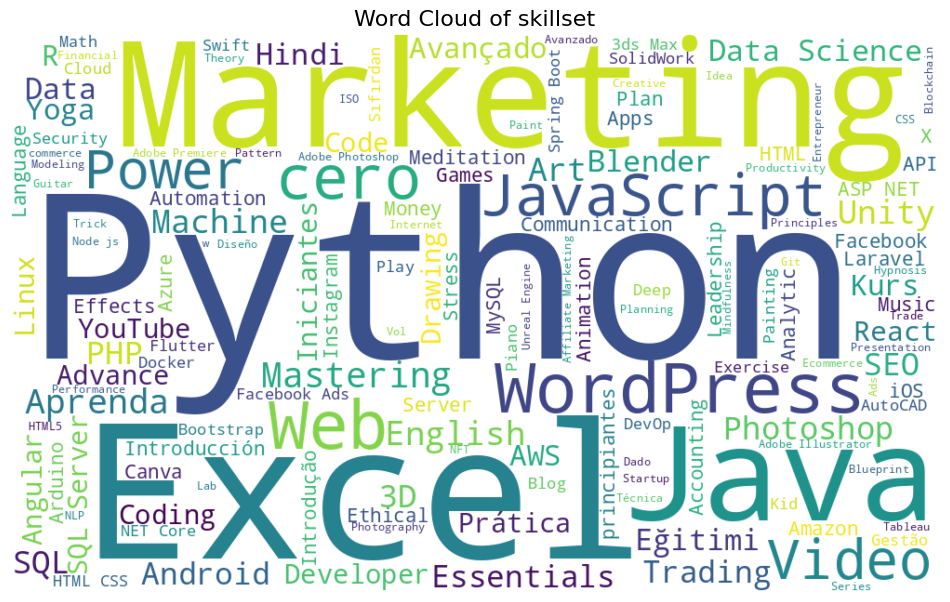

In [76]:
all_text1 = ' '.join(df['title'])
stop_words = set(stopwords.words())
stopwords1 = [
    "Beginner", "Beginners", "Complete", "Learn", "Course", "Advanced", "Masterclass","Guide", "Ultimate", "Tutorial", "Create", "Training", "Master", "Fundamental", 
    "Fundamentals", "Basic", "Basics", "Using", "Part", "Build", "Make", "level","levels", "Essential", "Start", "Step", "de", "e", "Zero", "Hero", "Become", 
    "Scratch", "Professional", "Introduction", "Building", "Easy", "Secret", "la","new", "Bootcamp", "Made", "Use", "Mastery", "Para", "Absolute", "Pro", "Full",
    "practical", "online", "write", "curso", "con", "hour", "day", "skill","foundation", "strategy", "system", "technique", "tool", "work",
    'Learn','Practice','Create','Scratch','Introduction','Zero','Tutorial','Completo','Write','Level',"Practica",'Workshop','Success','Kursu','principiante',
    'Manager','Simple','Effect','Step',"Learning", "Test", "Design", "Exam","Certificate", "Certification", "Class", "Online", 
    "Training", "Fundamentals", "Masterclass", "Introduccion", "Básico", "Práctica","Principiante", "Desenvolvimento", "Iniciante", "Intermédiate", "Creating", 
    "Building", "Grow", "Improve", "Develop", "Selling", "Writing", "Doing", "Making","Working", "Live", "Tips", "Project", "Management", "Analysis", "Question", 
    "Development", "Secrets", "Tools", "Steps", "System", "Method", "Skills","Foundation", "Business", "Minutes", "Hours", "Days", "Step", "Crash",
    "Hand", "Best", "Quick", "Real", "World", "Aprende", "Curso", "Social", "Media","Understanding", "Book", "Prep", "Crea", "Successful", "Window", "Time", 
    "Programming", "App", "Life", "Hands", "Comprehens",    "Agile", "Modern", "Based", "Digital", "Sales", "Sell", "Job", "Started", "Career",
    "Health", "Top", "Home", "Model", "Program", "Desenv", "Proje", "Projeto","Espanol", "Framework", "Solid", "Solido", "Expert", "Emprendedor", 
    "Personal", "Fast", "Hacking", "Program", "Scrum", "Certified", "Website","Application", "Desktop", "Mobile", "Game", 
    "Testing", "Quality", "Assurance", "QA","Software", "Prince2", "Finance", "Investment", 
    "Business", "Analyst", "Strategy", "Management", "HR", "Human","Resources", "Content", "Copywriting", "Advertising", "Customer", 
    "Service", "CRM", "E-commerce", "Shopify", "Motion", "Graphics","Production", "Audio", "Engineering", "Office", "Microsoft", "Word", 
    "PowerPoint", "Access", "Outlook", "Google", "Sheets","Docs", "Slides", "Forms", "Admin", "Administration", "Windows", 
    "MacOS", "Penetration", "Testing", "Analyst","Fundamentals", "Basics", "Advanced","Intermediate", "Expert", "Beginner", "Complete", "Masterclass", "Guide", 
    "Ultimate", "Tutorial", "Create", "Training", "Master", "Fundamental", "Basic","Using", "Part", "Build", "Make", "Level", "Essential", "Start", "Step", "Hero", 
    "Become", "Scratch", "Professional", "Introduction", "Building", "Easy","Secret", "Made", "Use", "Mastery", "Absolute", "Pro", "Full","Exams",'Coaching','Interview',
    'Serie','Free','Arabic','Strategie','Sistema','Lesson','Edition','Applications',"Lean",'Experto','Control','Product','Intro','Technical','base','Concepts','Projects','Lab'
    'Internet','Find','Comprehensive','Lessons','Passo','Examples','Creation','Principle','Process','Tests','Site','Corso','Fundamento','Paso','Effective','Fundamentos','Profesional',
    'Confidence','Techniques','Strategies','Preparation','Change','Team','Draw','Questions'
]
stop_words= stop_words | set(stopwords1)
# Generate the word cloud
wordcloud = WordCloud(width=1000, height=600,stopwords=stop_words, background_color='white',
                      max_words=150, colormap='viridis').generate(all_text1)
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of skillset', fontsize=16)
plt.show()

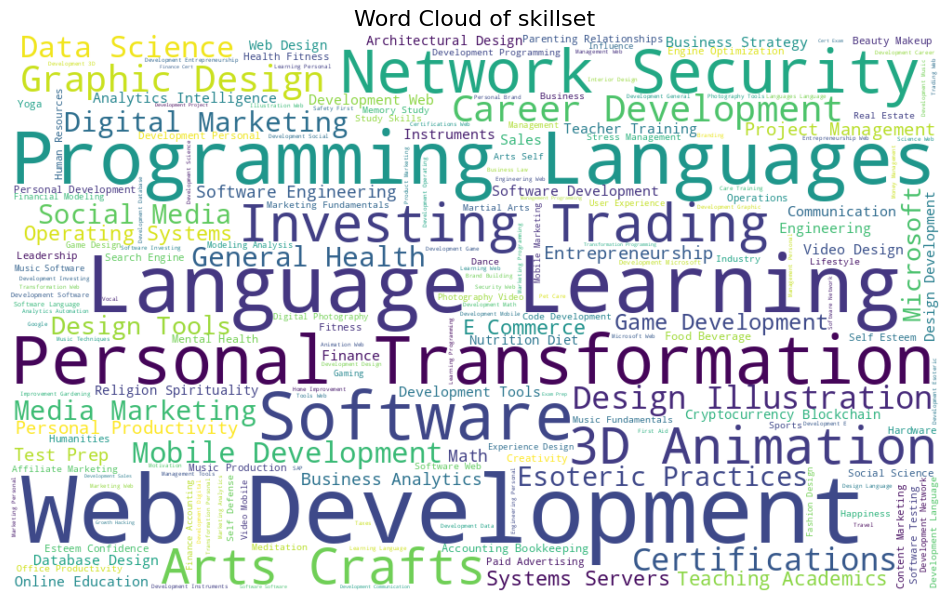

In [77]:
all_text = ' '.join(df['subcategory'])
stop_words = set(stopwords.words('english'))
# Generate the word cloud
wordcloud = WordCloud(width=1000, height=600,stopwords=stop_words, background_color='white',
                      max_words=200, colormap='viridis').generate(all_text)
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of skillset', fontsize=16)
plt.show()
# most of the courses are related to subcategories like web development, language learning, Programming languages, personal transformation etc.

In [78]:
# df[df['subcategory'].str.contains('photography',case=False)]
df['subcategory'].unique()

array(['Food & Beverage', 'Other Lifestyle', 'Pet Care & Training',
       'Yoga', 'Investing & Trading', 'Programming Languages', 'Media',
       'Search Engine Optimization', 'Mobile Development',
       'IT Certifications', 'Web Development', 'Design Tools', 'Science',
       'Web Design', 'Teacher Training', 'General Health',
       'Communication', 'Microsoft', 'Digital Marketing',
       'Language Learning', 'Hardware', 'Entrepreneurship',
       'Marketing Fundamentals', 'Sales',
       'Business Analytics & Intelligence',
       'Database Design & Development', 'Game Development',
       'Content Marketing', 'Social Media Marketing', 'Social Science',
       'Operations', 'Instruments', 'Industry',
       'Parenting & Relationships', 'Other Business', 'Management',
       'Home Improvement & Gardening', 'Photography',
       'Graphic Design & Illustration', 'Arts & Crafts',
       'Online Education', 'Affiliate Marketing', 'Esoteric Practices',
       'Career Development', 'Hum

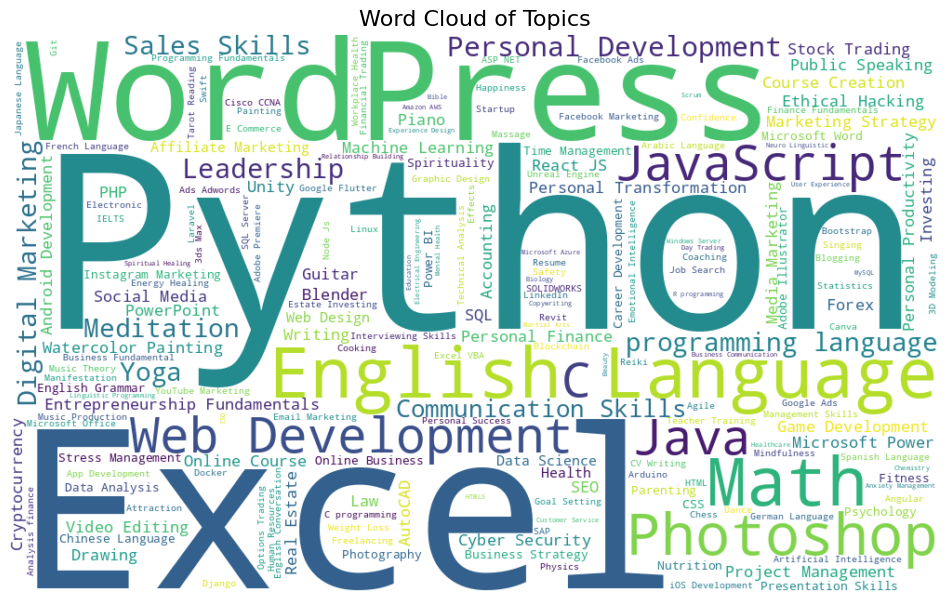

In [79]:
all_text = ' '.join(df['topic'])
stop_words = set(stopwords.words('english'))
# Generate the word cloud
wordcloud = WordCloud(width=1000, height=600,stopwords=stop_words, background_color='white',
                      max_words=200, colormap='viridis').generate(all_text)
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Topics', fontsize=16)
plt.show()
# most of the courses are related to Topics like web Python,Excel, Photoshop, Wordpress, English language, etc.

### Finding Top courses

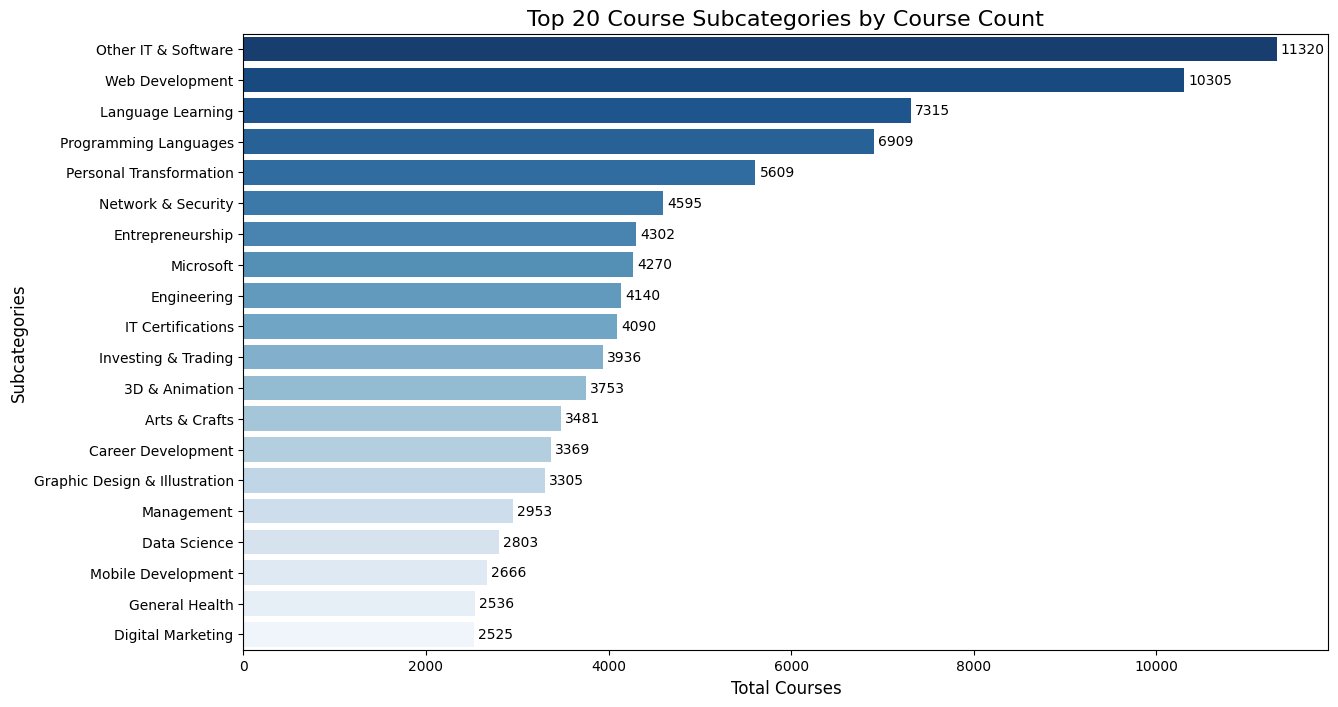

In [80]:
# Count the number of courses in each subcategory
course_counts = df['subcategory'].value_counts().head(20).sort_values(ascending=False)
plt.figure(figsize=(14, 8))

# Create the bar plot directly from the pandas Series
ax= sns.barplot(x=course_counts.values, y=course_counts.index, palette="Blues_r", orient='h')

# Add the title and axis labels
plt.title('Top 20 Course Subcategories by Course Count', fontsize=16)
plt.xlabel('Total Courses', fontsize=12)
plt.ylabel('Subcategories', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type="edge", padding=3)
plt.show()

In [81]:
# --- Top 20 Most Popular Courses by Average Rating ---
# Note: It's better to sort by avg_rating and then break ties with num_subscribers for "popularity"
top_courses = df.sort_values(by=['avg_rating', 'num_subscribers'], ascending=[False, False]).head(20)
print("\nTop 20 Most Popular Courses:")
print(top_courses[['title', 'avg_rating', 'num_subscribers']].to_string(index=False))


Top 20 Most Popular Courses:
                                                       title  avg_rating  num_subscribers
                   Small Business Fundamentals Crash Course.         5.0          36609.0
                Marketing For Small Businesses Crash Course.         5.0          30140.0
                    Abdomen Definido y Fuerte - Buff Academy         5.0          22187.0
              How To Master The Law of Attraction- Abundance         5.0          17883.0
                 How to get Paid to Travel The World in 2022         5.0          17390.0
The Ultimate Guide to Stencil for Merch By Amazon, KDP & POD         5.0          16035.0
                                   Autogestão para o sucesso         5.0          15553.0
    YouTube Live Masterclass 1: YouTube Live Creates Revenue         5.0          14661.0
  Bitcoin & Ethereum CryptoCurrency Course (2 Course Bundle)         5.0          13405.0
           PMI-ACP Certification: Adopting an Agile Approach         5

### Popular courses

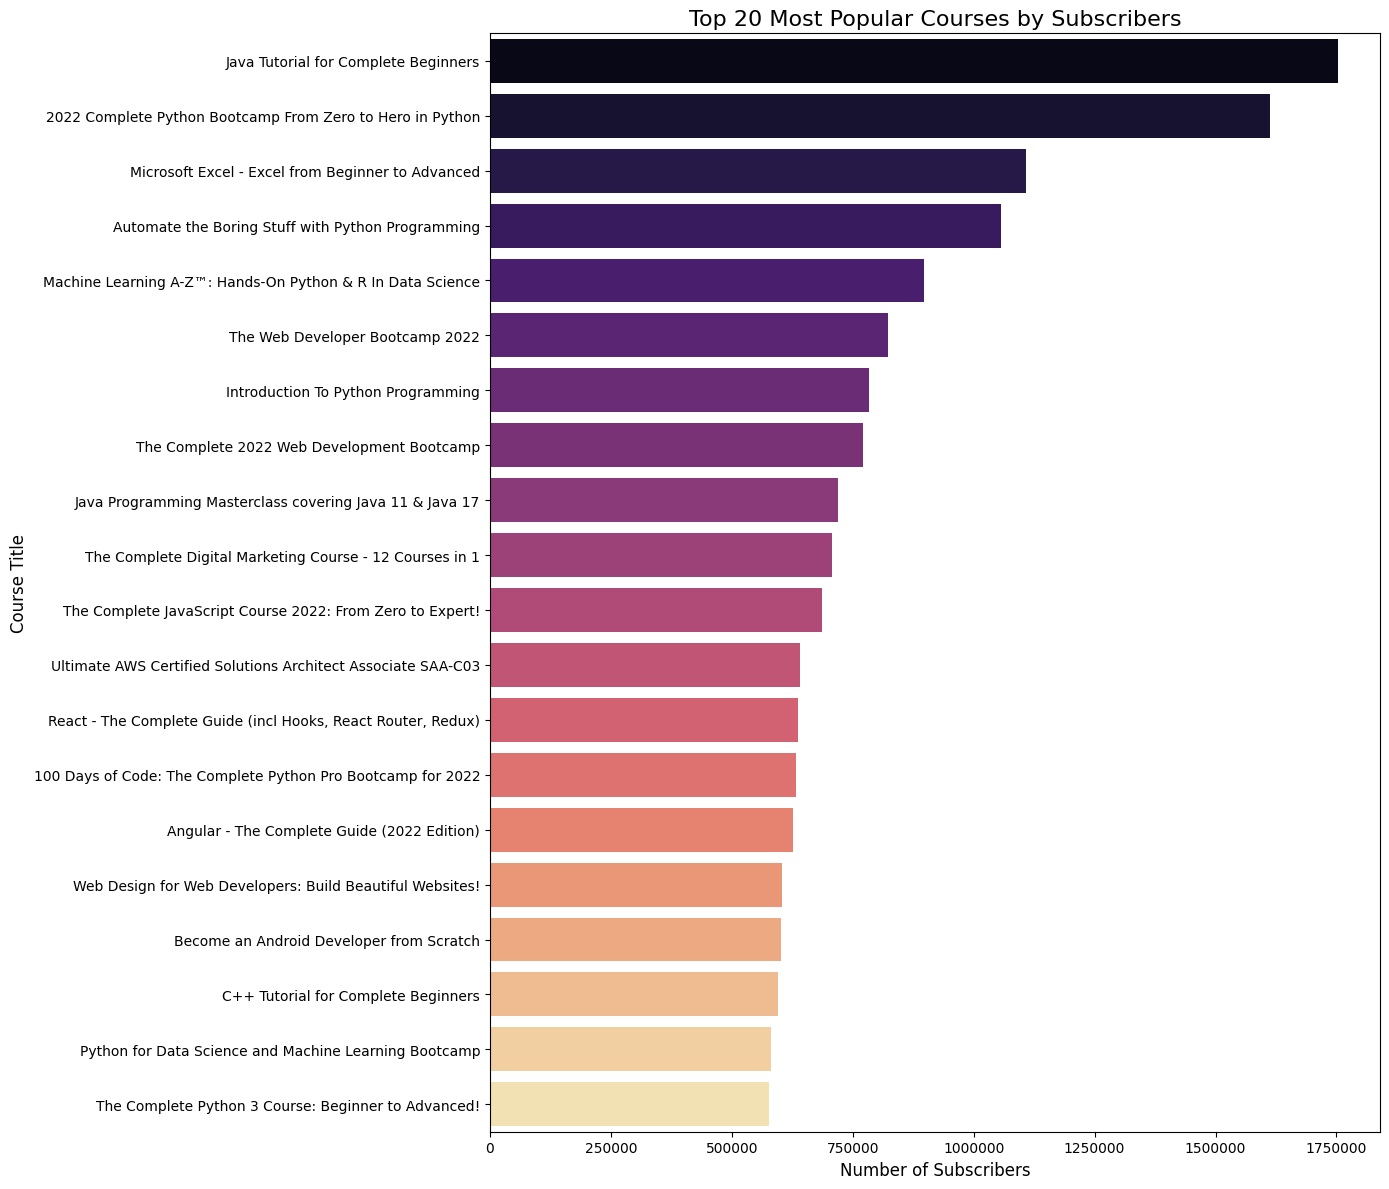

In [82]:
# Popularity can be defined by a combination of 'avg_rating' and 'num_subscribers'.
# Let's define it as the courses with the highest number of subscribers.
top_courses = df.sort_values(by='num_subscribers', ascending=False).head(20)

plt.figure(figsize=(14, 12))
sns.barplot(x='num_subscribers', y='title', data=top_courses, palette='magma', hue='title')
plt.title('Top 20 Most Popular Courses by Subscribers', fontsize=16)
plt.xlabel('Number of Subscribers', fontsize=12)
plt.ylabel('Course Title', fontsize=12)
# plt.xticks(np.arange(0, 100001, step=10000))
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='x')
plt.show()

### Preprocessing for vector database creation

In [83]:
#remove special characters, numbers, and extra spaces; convert to lowercase
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text, flags=re.UNICODE)  # # Use Unicode properties to keep letters from all languages, numbers, and spaces
    text = " ".join(text.split())            # Remove extra spaces
    return text

text_cols = ['title', 'headline']
for col in text_cols:
    df[col] = df[col].apply(preprocess_text)

In [84]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
stop_words.update(["getting started", "using", "enabling", "template", "university", "end", "introduction", "basic", "learn", "learning", "udemy","model", "desenv", 
    "instructor", "instructors", "new", "best", "top", "great", "knowledge", "skill", "skills", "skillset", "skillsets", "skillful", "skillfully", "skillfulness", "home", 
    'beginner','advanced','intermediate','advance','fundamentals','fundamental','complete','masterclass','practical','build','guide','know','visual','services',"solid",
    'start', 'project','basics', 'beginners', 'scratch','application', 'projects', 'world','apps', 'app', 'getting', 'driven','easy',"strategy",'need', 'code',"penetration", 
    "course",  "create", "training", "master",  "solido", 'real','tool', "essential", "step", "de", "e", "zero", "hero", "become", "fast", "certified","framework",
    "part", "make", "level","levels", "certificate", "certification", "class",'techniques','strategies',"proje",'manager','simple','effect',
    "professional",  "building","secret", "la", "bootcamp", "use", "para", "absolute", "pro", "online", "con", "hour", "day", "foundation",'zero',"ultimate",   
    'practice','zero','tutorial','completo','write',"practica",'workshop','success','kursu','principiante',"minutes", "hours", "days",  "crash",'time',
    "introduccion", "básico", "práctica","principiante", "desenvolvimento", "iniciante", "intermédiate", "creating", 'preparation','change','team','draw','questions'
    "grow", "improve", "develop", "writing", "doing", "making","working", "live", "tips", "question","secrets", "tools", "steps","system", "method", "foundations", 
    "hand", "quick","aprende", "curso", "social","understanding", "book", "prep", "crea", "successful", "window", "time",  "projeto", "test", "design", "exam",
    "hands", "comprehens","agile", "modern", "based","sell", "job", "started", "career", 'profesional', 'confidence', "desktop","assurance",  "website","expert",
    "service", "admin", "administration", "systems", "technique", "work","made", "mastery","full","exams",'coaching','interview',"emprendedor",'coding', 
    'serie','free','strategie','sistema','lesson','edition','applications',"lean",'experto','control','product','intro','technical','base','concepts','lab'
    'internet','find','comprehensive','lessons','passo','examples','creation','principle','process','tests','site','corso','fundamento','paso','effective','fundamentos',
])

# Mapping NLTK POS tags to WordNet POS tags for better lemmatization
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default noun

def lemmatize_texts(texts):
    lemmas_list = []
    for text in texts:
        tokens = word_tokenize(text)
        filtered_tokens = [tok for tok in tokens if tok.lower() not in stop_words and len(tok) > 1]

        pos_tags = pos_tag(filtered_tokens)
        lemmas = []
        for token, tag in pos_tags:
            wn_tag = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(token, wn_tag)
            # Override lemma for 'datum' to keep as 'data'
            if lemma == 'datum' and token.lower() == 'data':
                lemma = 'data'
            lemmas.append(lemma)
        lemmas_list.append(" ".join(lemmas))
    return lemmas_list

#combine title and headline columns
df['combined_text'] = df['title'] + ' ' + df['headline']
df['lemmatized_text'] = lemmatize_texts(df['combined_text'])
# Lemmatize the combined_text column and include category, subcategory, language
df['processed_text'] = df['lemmatized_text'] +  ' ' + df['category'] +  ' ' + df['subcategory'] + ' ' + df['language'] + ' ' + df['is_paid'] + ' ' + df['content_length_minutes']

In [85]:
df['processed_text'].apply(lambda x: len(x.split()))

0         24
1         15
2         24
3         19
4         21
          ..
199115    16
199116    13
199117    12
199118    19
199119    25
Name: processed_text, Length: 199120, dtype: int64

In [86]:
max(df['processed_text'].apply(lambda x: len(x.split())))
# maximum length of processed text is 43 words, which will be max tokens in a single sample

48

Langchain documents

In [87]:
# converting published_time and last_update_date to date format for LLM metadata filtering and retrieval
df['published_time'] = df['published_time'].dt.tz_localize(None).dt.date
# df['last_update_date'] = df['last_update_date'].dt.tz_localize(None).dt.date

In [88]:
#drop columns which are not required for recommendation system
columns_drop_list = ['id','last_update_date','topic','instructor_name', 'instructor_url','num_reviews','num_comments','category','num_lectures','content_length_min','combined_text', 'lemmatized_text','headline']
df = df.drop(columns=[col for col in columns_drop_list if col in df.columns], axis=1)

In [89]:
df.reset_index(drop=True, inplace=True)
## export to excel in xls format
df.to_excel("data/udemy_data_cleaned.xlsx", index=False)

## Vector creation in chromaDB

In [90]:
df1 = pd.read_excel("data/udemy_data_cleaned.xlsx")
df1.isnull().sum()

title                     0
is_paid                   0
price                     0
num_subscribers           0
avg_rating                0
published_time            0
subcategory               0
language                  0
course_url                0
content_length_minutes    0
processed_text            0
dtype: int64

In [91]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from langchain.docstore.document import Document
import pandas as pd
# Initialize the embedding model
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedding_model = HuggingFaceEmbeddings(model_name=model_name)

df = pd.read_excel("data/udemy_data_cleaned.xlsx")

documents = []
for _, row in df.iterrows():
    metadata = {
        "title": row["title"],
        "is_paid": row["is_paid"],
        "price": row["price"],
        "num_subscribers": row["num_subscribers"],
        "avg_rating": row["avg_rating"],
        "published_time": row["published_time"].year,
        "subcategory": row["subcategory"],
        "language": row["language"],
        "course_url": row["course_url"],
        "content_length_minutes": row["content_length_minutes"]

    }
    documents.append(Document(page_content=row["processed_text"], metadata=metadata))

# Create a persistent Chroma DB (stored locally in ./chroma_db)
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    persist_directory="./chroma_db"
)
# Save to disk
vectorstore.persist()

C:\Users\abhik\AppData\Local\Temp\ipykernel_25068\528755382.py:35: LangChainDeprecationWarning:

Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.



In [3]:
UNIQUE_LANGUAGES

['All',
 'Afrikaans',
 'Albanian',
 'Arabic',
 'Armenian',
 'Azeri',
 'Bengali',
 'Bulgarian',
 'Burmese',
 'Catalan',
 'Chinese',
 'Croatian',
 'Czech',
 'Danish',
 'Dutch',
 'English',
 'Estonian',
 'Filipino',
 'Finnish',
 'French',
 'Georgian',
 'German',
 'Greek',
 'Gujarati',
 'Haitian',
 'Hebrew',
 'Hindi',
 'Hungarian',
 'Indonesian',
 'Irish',
 'Italian',
 'Japanese',
 'Kannada',
 'Kazakh',
 'Khmer',
 'Korean',
 'Kurdish',
 'Latvian',
 'Lithuanian',
 'Macedonian',
 'Malay',
 'Malayalam',
 'Marathi',
 'Mongolian',
 'Nepali',
 'Norwegian',
 'Pashto',
 'Persian',
 'Polish',
 'Portuguese',
 'Punjabi',
 'Quechua',
 'Romanian',
 'Russian',
 'Serbian',
 'Slovak',
 'Slovenian',
 'Somali',
 'Spanish',
 'Swahili',
 'Swedish',
 'Tamil',
 'Telugu',
 'Thai',
 'Turkish',
 'Ukrainian',
 'Urdu',
 'Uzbek',
 'Vietnamese']